# Preparing Raw Data (Preparando conjunto de dados)

This is necessary to try any subsection of this Notebook, so execute it!

---

Essa parte é necessária para executar qualquer subseção desse Notebook, portanto, é necessário executá-la sempre.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Literal, Any

In [2]:
TESTED_MODES = np.arange(1, 33, dtype=int)
TESTED_MODES_FULL_ORDER = np.arange(1, 100, 5, dtype=int)
TRAIN_SPLIT = 2/3
# Kernels disponíveis para uso pelo SKLearn
SIMULATIONS = [
    'collision',
    'spreading'
]
KERNELS = {
    'poly': ['coef0', 'degree', 'gamma'],
    'rbf': ['gamma'],
    'sigmoid': ['coef0', 'gamma'],
}
RANGES = {
    'coef0': (-100., 100.),
    'degree': (1, 5),
    'gamma': (1e-8, 1.0),
}

In [3]:
np.random.seed(42)

In [4]:
collision_file = np.load(".data/Time_series_colisao.npz")
display(collision_file)
spreading_file = np.load(".data/Time_series_espalhamento.npz")
display(spreading_file)

NpzFile '.data/Time_series_colisao.npz' with keys: TS, Re, We, B

NpzFile '.data/Time_series_espalhamento.npz' with keys: TS, Re, We, Fr, V0...

In [5]:
simulations_objs = {}
collision_timesteps_raw = collision_file['TS']
display(f"Dimensions of the collision simulations: {collision_timesteps_raw.shape}")
display(f"That is, {collision_timesteps_raw.shape[0]} simulations, with {collision_timesteps_raw.shape[1]} timesteps each, having {collision_timesteps_raw.shape[2]} components each.")
simulations_objs['collision'] = {
    'timesteps_raw': collision_timesteps_raw,
}
spreading_timesteps_raw = spreading_file['TS']
display(f"Dimensions of the spreading simulations: {spreading_timesteps_raw.shape}")
display(f"That is, {spreading_timesteps_raw.shape[0]} simulations, with {spreading_timesteps_raw.shape[1]} timesteps each, having {spreading_timesteps_raw.shape[2]} components each.")
simulations_objs['spreading'] = {
    'timesteps_raw': spreading_timesteps_raw,
}
del collision_file, spreading_file

'Dimensions of the collision simulations: (72, 1000, 5)'

'That is, 72 simulations, with 1000 timesteps each, having 5 components each.'

'Dimensions of the spreading simulations: (132, 1000, 4)'

'That is, 132 simulations, with 1000 timesteps each, having 4 components each.'

# Reordering data

In [6]:
collision_timesteps_components_last = np.transpose(collision_timesteps_raw, (1, 0, 2))
display(f"Shape after transpose is: {collision_timesteps_components_last.shape}")
# Flattening 2nd and 3rd dimensions
collision_timesteps_components_last = (
    collision_timesteps_components_last
    .reshape(collision_timesteps_components_last.shape[0], -1)
)
display(f"Shape after flattening is: {collision_timesteps_components_last.shape}")
simulations_objs['collision']['original_data'] = collision_timesteps_components_last

'Shape after transpose is: (1000, 72, 5)'

'Shape after flattening is: (1000, 360)'

In [7]:
spreading_timesteps_components_last = np.transpose(spreading_timesteps_raw, (1, 0, 2))
display(f"Shape after transpose is: {spreading_timesteps_components_last.shape}")
# Flattening 2nd and 3rd dimensions
spreading_timesteps_components_last = (
    spreading_timesteps_components_last
    .reshape(spreading_timesteps_components_last.shape[0], -1)
)
display(f"Shape after flattening is: {spreading_timesteps_components_last.shape}")
simulations_objs['spreading']['original_data'] = spreading_timesteps_components_last

'Shape after transpose is: (1000, 132, 4)'

'Shape after flattening is: (1000, 528)'

# Scaling data

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(simulations_objs['collision']['original_data'])
display(f"Asserting mean = 0 and std = 1 for every column")
assert np.allclose(scaled_data.mean(axis=0), 0)
assert np.allclose(scaled_data.std(axis=0), 1)
display("Success!")
simulations_objs['collision']['scaled_data'] = scaled_data
simulations_objs['collision']['scaler'] = scaler

'Asserting mean = 0 and std = 1 for every column'

'Success!'

In [9]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(simulations_objs['spreading']['original_data'])
display(f"Asserting mean = 0 and std = 1 for every column")
assert np.allclose(scaled_data.mean(axis=0), 0)
assert np.allclose(scaled_data.std(axis=0), 1)
display("Success!")
simulations_objs['spreading']['scaled_data'] = scaled_data
simulations_objs['spreading']['scaler'] = scaler

'Asserting mean = 0 and std = 1 for every column'

'Success!'

In [10]:
import optuna
from sklearn.decomposition import KernelPCA

def objetive_function(trial: optuna.trial.Trial):
    studied_simulation = trial.study.user_attrs['studied_simulation']
    used_kernel = trial.study.user_attrs['used_kernel']
    studied_hyperparams = KERNELS[used_kernel]
    hyperparam_obj = {}
    if 'degree' in studied_hyperparams:
        degree = trial.suggest_int('degree', RANGES['degree'][0], RANGES['degree'][1])
        hyperparam_obj['degree'] = degree
    if 'gamma' in studied_hyperparams:
        gamma = trial.suggest_float('gamma', RANGES['gamma'][0], RANGES['gamma'][1], log=True)
        hyperparam_obj['gamma'] = gamma
    if 'coef0' in studied_hyperparams:
        coef0 = trial.suggest_float('coef0', RANGES['coef0'][0], RANGES['coef0'][1])
        hyperparam_obj['coef0'] = coef0
    permutation_idx = np.random.permutation(simulations_objs[studied_simulation]['scaled_data'].shape[0])
    number_of_timesteps = simulations_objs[studied_simulation]['scaled_data'].shape[0]
    number_of_timesteps_train = int(number_of_timesteps * TRAIN_SPLIT)
    training_idx = permutation_idx[:number_of_timesteps_train]
    testing_idx = permutation_idx[number_of_timesteps_train:]
    training_data = simulations_objs[studied_simulation]['original_data'][training_idx]
    training_data_scaled = simulations_objs[studied_simulation]['scaled_data'][training_idx]
    testing_data = simulations_objs[studied_simulation]['original_data'][testing_idx]
    testing_data_scaled = simulations_objs[studied_simulation]['scaled_data'][testing_idx]
    scaler = simulations_objs[studied_simulation]['scaler']
    mape_testing = float('inf')
    try:
        kpca = KernelPCA(n_components=TESTED_MODES_FULL_ORDER[-1], kernel=used_kernel, fit_inverse_transform=True, **hyperparam_obj)
        kpca.fit(training_data_scaled)
        reconstructed_training_scaled = kpca.inverse_transform(kpca.transform(training_data_scaled))
        reconstructed_training = scaler.inverse_transform(reconstructed_training_scaled)
        mape_training = (np.mean(np.abs(training_data - reconstructed_training)) / np.mean(np.abs(training_data))) * 100
        trial.set_user_attr('training_mape', mape_training)
        reconstructed_testing_scaled = kpca.inverse_transform(kpca.transform(testing_data_scaled))
        reconstructed_testing = scaler.inverse_transform(reconstructed_testing_scaled)
        mape_testing = (np.mean(np.abs(testing_data - reconstructed_testing)) / np.mean(np.abs(testing_data))) * 100
        trial.set_user_attr('testing_mape', mape_testing)
    except Exception as e:
        trial.set_user_attr('exception', e.__class__.__name__)
        print("Error in trial", e)
    return mape_testing

/home/guilherme/Repositories/data-driven-studies/droplet/.env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
from itertools import product

for simulation, kernel in product(SIMULATIONS, KERNELS.keys()):
    study = optuna.create_study(
        direction='minimize',
        study_name=f"{simulation}_{kernel}",
        storage=f"sqlite:///.optunadb/{simulation}_{kernel}.db",
        load_if_exists=True,
    )
    study.set_user_attr('studied_simulation', simulation)
    study.set_user_attr('used_kernel', kernel)
    remaining_to_500 = 500 - len(study.trials)
    study.optimize(objetive_function, n_trials=remaining_to_500, show_progress_bar=True)

[I 2024-10-18 17:00:15,536] A new study created in RDB with name: collision_poly
Best trial: 0. Best value: 19.7212:   0%|          | 1/500 [00:00<05:51,  1.42it/s]

[I 2024-10-18 17:00:16,265] Trial 0 finished with value: 19.721249694321582 and parameters: {'degree': 4, 'gamma': 2.4302167361130242e-08, 'coef0': -90.23405336020127}. Best is trial 0 with value: 19.721249694321582.


Best trial: 0. Best value: 19.7212:   0%|          | 2/500 [00:01<04:37,  1.79it/s]

[I 2024-10-18 17:00:16,718] Trial 1 finished with value: 20.507775332918648 and parameters: {'degree': 1, 'gamma': 5.118094793453352e-07, 'coef0': 20.223919299439245}. Best is trial 0 with value: 19.721249694321582.


Best trial: 2. Best value: 0.120881:   1%|          | 3/500 [00:01<04:27,  1.85it/s]

...

Error in trial Matrix is singular.
[I 2024-10-18 17:24:22,331] Trial 497 finished with value: inf and parameters: {'gamma': 0.3566518999807749, 'coef0': -9.009865317651098}. Best is trial 477 with value: 7.703900612849742.


Best trial: 477. Best value: 7.7039: 100%|█████████▉| 499/500 [04:05<00:00,  2.19it/s]

Error in trial Matrix is singular.
[I 2024-10-18 17:24:22,635] Trial 498 finished with value: inf and parameters: {'gamma': 0.11101926248412353, 'coef0': -2.601143952491303}. Best is trial 477 with value: 7.703900612849742.


Best trial: 477. Best value: 7.7039: 100%|██████████| 500/500 [04:05<00:00,  2.03it/s]

[I 2024-10-18 17:24:23,311] Trial 499 finished with value: 10.944160650807175 and parameters: {'gamma': 0.08082004729676402, 'coef0': 0.17700924370715043}. Best is trial 477 with value: 7.703900612849742.


In [25]:
study_poly_collision = optuna.load_study(
    study_name='collision_poly',
    storage=f"sqlite:///.optunadb/collision_poly.db",
)

In [ ]:
df = study_poly_collision.trials_dataframe()[["params_degree", "params_gamma", "params_coef0", "value"]].replace(np.inf, np.nan).dropna()

degrees = np.sort(study_poly_collision.trials_dataframe()["params_degree"].dropna().unique())
for degree in degrees:
    fig, ax = plt.subplots(figsize=(10, 10))    
    df_filtered = df.query(f"params_degree == {degree}")
    print(df_filtered)
    ax.scatter(df_filtered["params_gamma"], df_filtered["params_coef0"], c=df_filtered["value"], cmap='RdYlGn_r')
    ax.set_xlabel('Gamma')
    ax.set_xscale('log')
    ax.set_ylabel('Coef0')
    ax.set_title(f"Degree = {degree}")
    plt.show()

In [12]:
study_rbf_collision = optuna.load_study(
    study_name='collision_rbf',
    storage=f"sqlite:///.optunadb/collision_rbf.db",
)

In [13]:
study_rbf_collision.trials_dataframe()

,number,value,datetime_start,datetime_complete,duration,params_gamma,user_attrs_testing_mape,user_attrs_training_mape,state
0,0,20.395579,2024-10-18 17:04:34.167156,2024-10-18 17:04:34.495122,0 days 00:00:00.327966,3.242212e-05,20.395579,19.492299,COMPLETE
1,1,11.837393,2024-10-18 17:04:34.524905,2024-10-18 17:04:34.963342,0 days 00:00:00.438437,5.828773e-01,11.837393,8.571146,COMPLETE
2,2,20.214128,2024-10-18 17:04:35.003903,2024-10-18 17:04:35.353989,0 days 00:00:00.350086,8.668674e-08,20.214128,19.299222,COMPLETE
3,3,20.603375,2024-10-18 17:04:35.380942,2024-10-18 17:04:35.785585,0 days 00:00:00.404643,1.541510e-08,20.603375,18.909477,COMPLETE
4,4,20.108414,2024-10-18 17:04:35.831932,2024-10-18 17:04:36.322166,0 days 00:00:00.490234,3.276576e-06,20.108414,19.508752,COMPLETE
...,...,...,...,...,...,...,...,...,...
495,495,8.672200,2024-10-18 17:08:07.602287,2024-10-18 17:08:07.938364,0 days 00:00:00.336077,1.289324e-01,8.672200,8.040949,COMPLETE
496,496,9.886275,2024-10-18 17:08:07.989162,2024-10-18 17:08:08.323767,0 days 00:00:00.334605,3.182848e-01,9.886275,8.133867,COMPLETE
497,497,9.320414,2024-10-18 17:08:08.359609,2024-10-18 17:08:08.834768,0 days 00:00:00.475159,2.278977e-01,9.320414,7.685187,COMPLETE
498,498,9.014638,2024-10-18 17:08:08.871588,2024-10-18 17:08:09.435098,0 days 00:00:00.563510,6.112925e-02,9.014638,8.722591,COMPLETE


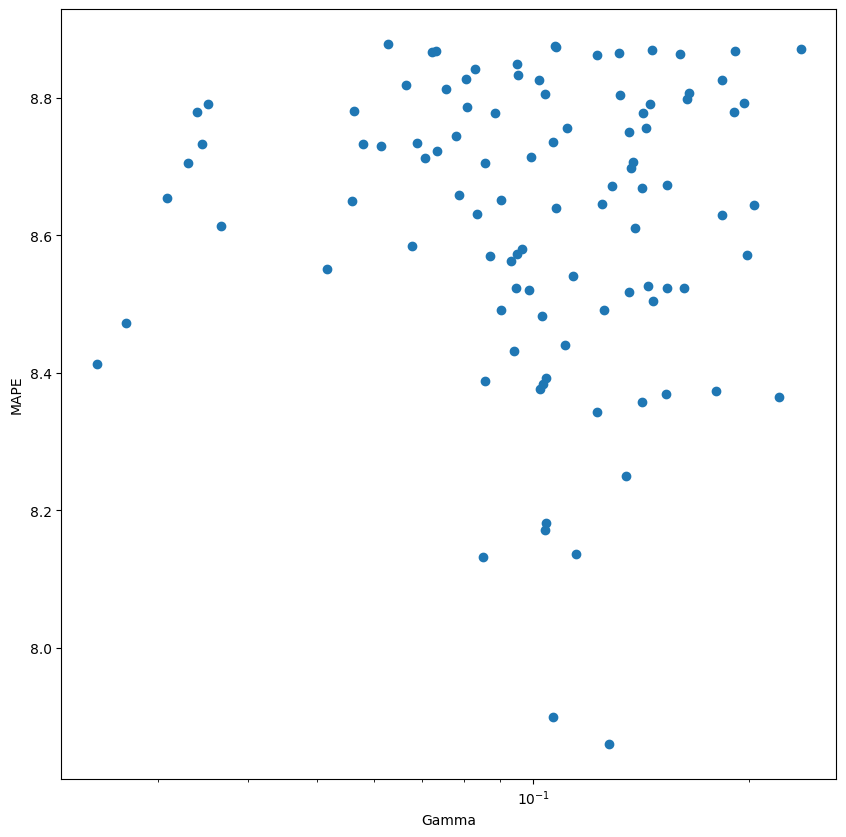

In [14]:
df = study_rbf_collision.trials_dataframe()[["params_gamma", "value"]].replace(np.inf, np.nan).dropna().sort_values(by="value").head(100)

fig, ax = plt.subplots(figsize=(10, 10))    
ax.scatter(df["params_gamma"], df["value"])
ax.set_xlabel('Gamma')
ax.set_xscale('log')
ax.set_ylabel('MAPE')
plt.show()